100%|██████████| 499/499 [00:01<00:00, 429.18it/s]


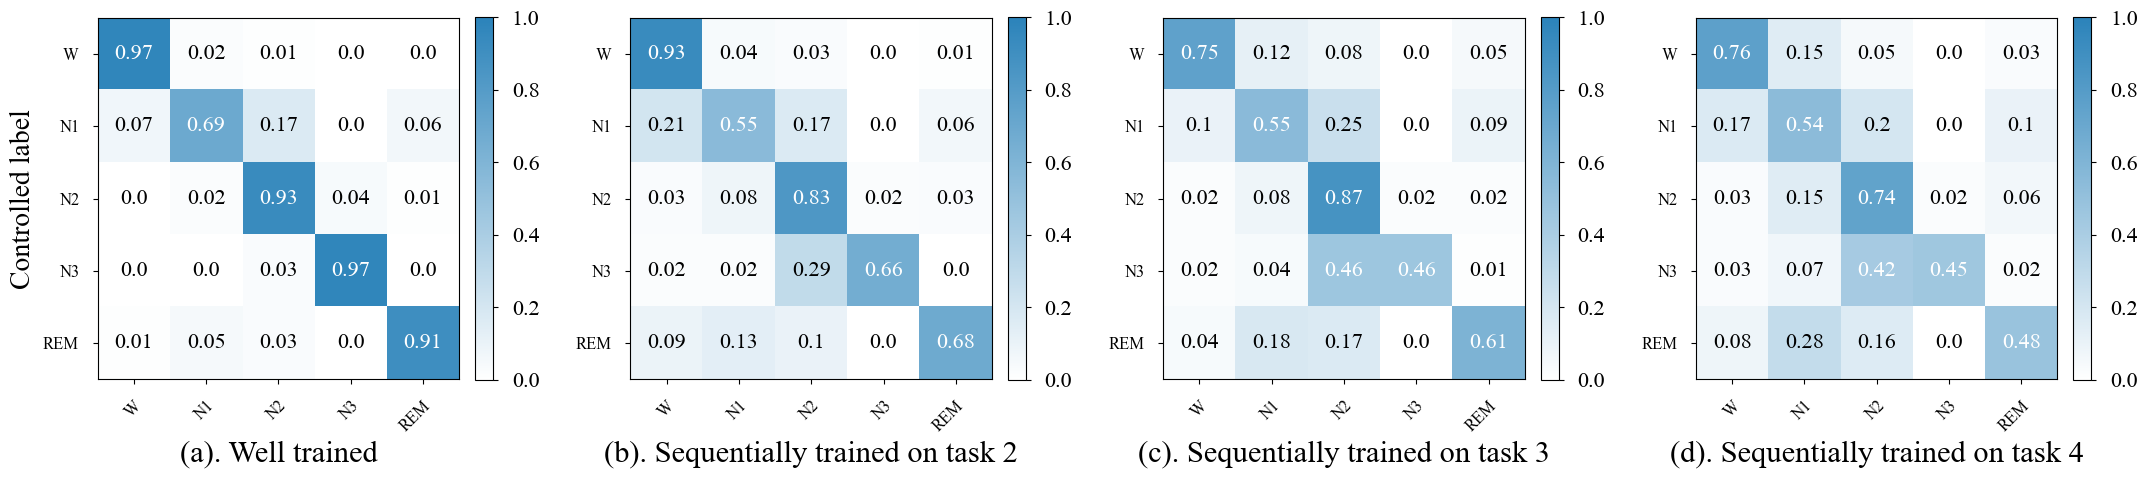

In [25]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
from GeCoSleep import *
from matplotlib.colors import LinearSegmentedColormap
from baselines import *
from tqdm import tqdm

num_samples = 64
device = torch.device(f'cuda:{0}')

generator = SequentialVAE(512, 0)
solver = MultiHeadSleepNet(2, 0, 4, False)
model_paths = [
    f'..\\modelsaved\\seq_gen_task{i}_fold0.pth'
    for i in range(4)
]
solver_paths = [
    f'..\\modelsaved\\generative_task{i}_fold0.pth'
    for i in range(4)
]

generator.eval()
generator.to(device)
solver.eval()
solver.to(device)
preds, labels = [], []
batch_size = 32
with torch.no_grad():
    for i in range(4):
        solver.load_state_dict(torch.load(solver_paths[i], map_location=device, weights_only=True))
        F = torch.load(f'./datacache/task{i}_gen_feature.pt', weights_only=True, map_location=device)
        y = torch.load(f'./datacache/task{i}_label.pt', weights_only=True, map_location=device)
        y_hat_list, y_list = [], []
        for j in tqdm(range(F.shape[0] // batch_size)):
            F_slice = F[j * batch_size: (j + 1) * batch_size, :, :]
            y_slice = y[j * batch_size: (j + 1) * batch_size, :]
            y_hat = solver.classify(F_slice, 0)
            y_hat = torch.argmax(y_hat, dim=1)
            y_hat_list.append(y_hat)
            y_list.append(y_slice)
        y_hat_list = torch.cat(y_hat_list, dim=0)
        y_list = torch.cat(y_list, dim=0)
        preds.append(y_hat_list.view(-1).cpu().numpy())
        labels.append(y_list.view(-1).cpu().numpy())

confusion_matrices = []

for pred, label in zip(preds, labels):
    cm = np.zeros((5, 5), np.int64)
    for i in range(pred.shape[0]):
        cm[label[i]][pred[i]] += 1
    cm = cm / np.sum(cm, axis=1, keepdims=True)
    cm = np.round(cm, decimals=2)
    confusion_matrices.append(cm)

plt.rcParams.update({
    'font.family': 'Times New Roman',          # 字体（优先使用无衬线字体）
    'font.size': 24,                 # 基础字号
    'axes.titlesize': 16,            # 标题字号
    'axes.labelsize': 16,            # 坐标轴标签字号
    'xtick.labelsize': 16,           # X轴刻度字号
    'ytick.labelsize': 16,           # Y轴刻度字号
    'xtick.major.pad': 10,  # X轴刻度标签与轴的距离（默认：3.5）
    'ytick.major.pad': 10,  # Y轴刻度标签与轴的距离（默认：3.5）
    'axes.grid': False,               # 显示网格
    'grid.alpha': 1,               # 网格透明度
    'axes.prop_cycle': plt.cycler(color=plt.cm.tab10.colors)  # 使用高对比度色环
})

# 子图标题
titles = [
    "After trained on task 1",
    "After trained on task 2",
    "After trained on task 3",
    "After trained on task 4"
]

# 类别标签
classes = ['W', 'N1', 'N2', 'N3', 'REM']

# 创建2x2的子图布局
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# 创建自定义颜色映射
cmap = LinearSegmentedColormap.from_list('custom_cmap', ['#ffffff', '#2b83ba'])

cnt, xlabels = 0, ['(a). Well trained', '(b). Sequentially trained on task 2', '(c). Sequentially trained on task 3', '(d). Sequentially trained on task 4']
# 为每个子图绘制不同的混淆矩阵
for ax, matrix, title in zip(axes.flat, confusion_matrices, titles):
    # 绘制热力图
    im = ax.imshow(matrix, interpolation='nearest', cmap=cmap, vmin=0, vmax=1)

    # 为每个子图添加独立的颜色条
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # 添加数值标签
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            color = 'black' if matrix[i, j] < np.max(matrix) / 2 else 'white'
            ax.text(j, i, str(matrix[i, j]),
                    ha="center", va="center", color=color, fontsize=16)

    # 设置坐标轴
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, fontsize=12)
    ax.set_yticklabels(classes, fontsize=12)

    if (cnt == 0):
        ax.set_ylabel("Controlled label", labelpad=5, fontsize=20)

    # 旋转x轴标签
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # 添加标题和标签
    ax.set_xlabel(xlabels[cnt], fontsize=22)
    cnt += 1

# 调整布局
plt.tight_layout()
plt.savefig('./figure/confusion_matrix.png')
plt.show()
